# Reproducing Figure 3 — Categorical target representations

Direct reproduction of Figure 3 in Klein et al. (2026), *Plasticity Loss in Deep
Reinforcement Learning: A Survey* (figure originally from Farebrother et al., 2024).

Three ways to turn a value-regression target into a categorical target over a fixed
support of atoms $z_1,\dots,z_5$, matching the paper's two-tier layout: the target
representation on top, the resulting probability bars $p_1,\dots,p_5$ below.

- **Two-hot** (Schrittwieser et al., 2020): mass on the two atoms bracketing a scalar target.
- **HL-Gauss** (Imani & White, 2018): a fixed-width Gaussian integrated over each bin.
- **C51** (Bellemare et al., 2017): a return distribution propagated through the Bellman
  map $r+\gamma Z$ and projected back onto the support.

Each mapping is deterministic and defined by a published formula: no data, no training,
no random seed. Running this notebook writes `../figures/fig3_categorical_losses.png`
and `../results/categorical_masses.csv`.

In [1]:
import os
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

CWD = os.getcwd()
ROOT = os.path.dirname(CWD) if os.path.basename(CWD) == "code" else CWD
FIG = os.path.join(ROOT, "figures"); RES = os.path.join(ROOT, "results")
os.makedirs(FIG, exist_ok=True); os.makedirs(RES, exist_ok=True)
NAVY, RED, GREY = "#12233f", "#b8443a", "#9aa0a6" 

## Support and parameters

Five atoms, matching the paper's schematic. The original states no numeric values;
these are documented choices.

In [2]:
V_MIN, V_MAX, N_ATOMS = -1.0, 1.0, 5
atoms = np.linspace(V_MIN, V_MAX, N_ATOMS)      # [-1, -0.5, 0, 0.5, 1]
dz = atoms[1] - atoms[0]                         # 0.5
edges = np.concatenate(([atoms[0] - dz / 2],
                        (atoms[:-1] + atoms[1:]) / 2,
                        [atoms[-1] + dz / 2]))
pos = np.arange(N_ATOMS)                          # plotting positions 0..4
def to_pos(v):                                    # value -> plotting position
    return (np.asarray(v) - V_MIN) / dz

Y_TARGET = 0.20        # scalar target for two-hot and HL-Gauss
SIGMA = 1.0 * dz       # HL-Gauss Gaussian width
C51_REWARD = 0.10      # r in the Bellman map r + gamma*Z
C51_GAMMA = 0.80       # gamma

## The three mappings, each from its defining equation

In [3]:
def two_hot(y, atoms):
    """Linear-interpolation two-hot encoding of scalar y onto `atoms`."""
    m = np.zeros_like(atoms)
    y = np.clip(y, atoms[0], atoms[-1])
    u = np.searchsorted(atoms, y)
    if atoms[u] == y:
        m[u] = 1.0
        return m
    lo = u - 1
    frac = (y - atoms[lo]) / (atoms[u] - atoms[lo])
    m[lo] = 1.0 - frac
    m[u] = frac
    return m


def hl_gauss(y, edges, sigma):
    """HL-Gauss: integrate N(y, sigma^2) over each bin defined by `edges`."""
    cdf = norm.cdf(edges, loc=y, scale=sigma)
    m = np.diff(cdf)
    return m / m.sum()


def c51_project(src_probs, atoms, r, gamma, v_min, v_max):
    """Categorical (C51) projection of the Bellman target r + gamma*atoms."""
    dz = atoms[1] - atoms[0]
    m = np.zeros_like(atoms)
    for p, z in zip(src_probs, atoms):
        Tz = np.clip(r + gamma * z, v_min, v_max)
        b = np.clip((Tz - v_min) / dz, 0.0, len(atoms) - 1)
        lo, up = int(np.floor(b)), int(np.ceil(b))
        if lo == up:
            m[lo] += p
        else:
            m[lo] += p * (up - b)
            m[up] += p * (b - lo)
    return m

In [4]:
p_twohot = two_hot(Y_TARGET, atoms)
p_hlgauss = hl_gauss(Y_TARGET, edges, SIGMA)

# source return distribution Z for the C51 panel (peaked at the centre)
src = np.array([0.08, 0.22, 0.40, 0.22, 0.08]); src = src / src.sum()
Tz = C51_REWARD + C51_GAMMA * atoms          # Bellman image r + gamma*Z
p_c51 = c51_project(src, atoms, C51_REWARD, C51_GAMMA, V_MIN, V_MAX)

for name, p in [("two-hot", p_twohot), ("HL-Gauss", p_hlgauss), ("C51", p_c51)]:
    assert abs(p.sum() - 1.0) < 1e-9, f"{name} mass sums to {p.sum()}"
print("all three distributions sum to 1")

all three distributions sum to 1


## Save the per-bin mass table

In [5]:
masses = pd.DataFrame({
    "atom": np.round(atoms, 4),
    "two_hot": np.round(p_twohot, 4),
    "hl_gauss": np.round(p_hlgauss, 4),
    "c51_source": np.round(src, 4),
    "c51_projected": np.round(p_c51, 4),
})
masses.to_csv(os.path.join(RES, "categorical_masses.csv"), index=False)
masses

,atom,two_hot,hl_gauss,c51_source,c51_projected
0,-1.0,0.0,0.0274,0.08,0.032
1,-0.5,0.0,0.1585,0.22,0.180
2,0.0,0.6,0.3629,0.40,0.408
3,0.5,0.4,0.3310,0.22,0.316
4,1.0,0.0,0.1202,0.08,0.064


## Figure: two-tier layout matching the paper

Each panel shows the target representation in the upper band and the resulting
probability bars $p_1..p_5$ in the lower band, with arrows from the representation
down onto the atoms.

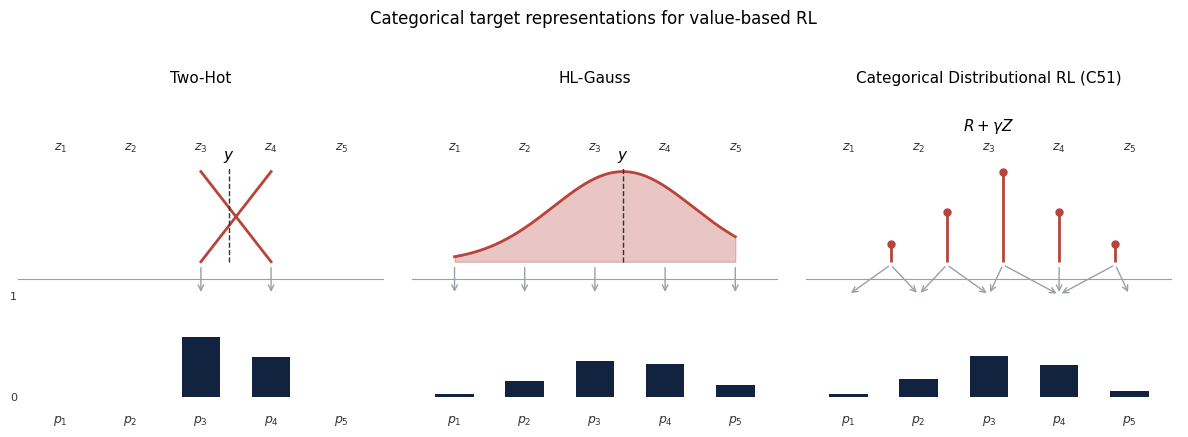

In [6]:
BASE, TOP = 1.35, 2.25          # representation band
def draw_bars(a, p, color):
    a.bar(pos, p, width=0.55, color=color, zorder=3)
def frame(a, title):
    a.plot([-0.6, 4.6], [1.18, 1.18], color=GREY, lw=0.8, zorder=1)
    for x in pos:
        a.text(x, -0.16, f"$p_{{{x+1}}}$", ha="center", va="top", fontsize=9, color="#333")
        a.text(x, 2.42, f"$z_{{{x+1}}}$", ha="center", va="bottom", fontsize=9, color="#333")
    a.set_xlim(-0.7, 4.7); a.set_ylim(-0.28, 2.95)
    a.set_title(title, fontsize=11, pad=14)
    a.axis("off")
def arrow(a, x0, x1):
    a.annotate("", xy=(x1, 1.02), xytext=(x0, BASE - 0.03),
               arrowprops=dict(arrowstyle="->", color=GREY, lw=1.0))

fig, ax = plt.subplots(1, 3, figsize=(12, 4.2))

# ---- panel 1: Two-Hot (interpolation X between the two bracketing atoms) ----
a = ax[0]
yp = to_pos(Y_TARGET)
lo = int(np.floor(yp)); up = lo + 1
a.plot([lo, up], [BASE, TOP], color=RED, lw=2)        # /
a.plot([lo, up], [TOP, BASE], color=RED, lw=2)        # \
a.plot([yp, yp], [BASE, TOP + 0.05], color="#333", lw=1, ls="--")
a.text(yp, TOP + 0.12, "$y$", ha="center", fontsize=11)
for x, w in [(lo, p_twohot[lo]), (up, p_twohot[up])]:
    a.plot(yp, BASE + (TOP - BASE) * (w if x == up else 1 - 0), "o", ms=0)  # keep scale
    arrow(a, x, x)
draw_bars(a, p_twohot, NAVY)
frame(a, "Two-Hot")
a.text(-0.62, 1.0, "1", ha="right", va="center", fontsize=8, color="#333")
a.text(-0.62, 0.0, "0", ha="right", va="center", fontsize=8, color="#333")

# ---- panel 2: HL-Gauss (Gaussian integrated over bins) ----
a = ax[1]
xs = np.linspace(V_MIN, V_MAX, 300); xp = to_pos(xs)
g = norm.pdf(xs, Y_TARGET, SIGMA); g = BASE + (g / g.max()) * (TOP - BASE)
a.fill_between(xp, BASE, g, color=RED, alpha=0.30, zorder=2)
a.plot(xp, g, color=RED, lw=2, zorder=2)
a.plot([to_pos(Y_TARGET)] * 2, [BASE, TOP + 0.05], color="#333", lw=1, ls="--")
a.text(to_pos(Y_TARGET), TOP + 0.12, "$y$", ha="center", fontsize=11)
for x in pos:
    arrow(a, x, x)
draw_bars(a, p_hlgauss, NAVY)
frame(a, "HL-Gauss")

# ---- panel 3: C51 (return distribution R + gamma*Z, projected onto atoms) ----
a = ax[2]
Tzp = to_pos(np.clip(Tz, V_MIN, V_MAX))
h = BASE + (src / src.max()) * (TOP - BASE)
a.vlines(Tzp, BASE, h, color=RED, lw=2, zorder=2)
a.plot(Tzp, h, "o", color=RED, ms=5, zorder=3)
a.text(2.0, 2.66, r"$R+\gamma Z$", ha="center", fontsize=11)
for xt in Tzp:
    lo = int(np.clip(np.floor(xt), 0, N_ATOMS - 1))
    up = int(np.clip(np.ceil(xt), 0, N_ATOMS - 1))
    for tgt in {lo, up}:
        arrow(a, xt, tgt)
draw_bars(a, p_c51, NAVY)
frame(a, "Categorical Distributional RL (C51)")

fig.suptitle("Categorical target representations for value-based RL", y=1.03, fontsize=12)
fig.tight_layout()
fig.savefig(os.path.join(FIG, "fig3_categorical_losses.png"), dpi=150, bbox_inches="tight")
plt.show()

## Summary statistics

In [7]:
def nonzero(p, tol=1e-6): return int((p > tol).sum())
def entropy(p): q = p[p > 0]; return float(-(q * np.log(q)).sum())

print(f"support: {N_ATOMS} atoms on [{V_MIN}, {V_MAX}], dz={dz:.3f}")
print(f"target y={Y_TARGET}, HL-Gauss sigma={SIGMA:.3f} ({SIGMA/dz:.1f} bin), "
      f"C51 r={C51_REWARD}, gamma={C51_GAMMA}")
print(f"two-hot mass: {np.round(p_twohot,3).tolist()}")
print(f"hl_gauss mass: {np.round(p_hlgauss,3).tolist()}")
print(f"c51 projected: {np.round(p_c51,3).tolist()}")
print(f"nonzero bins  two-hot={nonzero(p_twohot)}  hl_gauss={nonzero(p_hlgauss)}  c51={nonzero(p_c51)}")
print(f"entropy(nats) two-hot={entropy(p_twohot):.3f}  hl_gauss={entropy(p_hlgauss):.3f}  c51={entropy(p_c51):.3f}")

support: 5 atoms on [-1.0, 1.0], dz=0.500
target y=0.2, HL-Gauss sigma=0.500 (1.0 bin), C51 r=0.1, gamma=0.8
two-hot mass: [0.0, 0.0, 0.6, 0.4, 0.0]
hl_gauss mass: [0.027, 0.158, 0.363, 0.331, 0.12]
c51 projected: [0.032, 0.18, 0.408, 0.316, 0.064]
nonzero bins  two-hot=2  hl_gauss=5  c51=5
entropy(nats) two-hot=0.673  hl_gauss=1.379  c51=1.325
